# 基于互相关分析推断交通图边方向

- 使用时间序列互相关分析推断相邻传感器的上下游关系
- 按星期几聚合数据，降噪并多次验证
- 与基于 Abs_PM 的理论方向对比，计算精度

## 1. 环境配置

In [19]:
import pandas as pd
import numpy as np
from scipy import signal
from collections import Counter
import matplotlib.pyplot as plt
import os
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = "../output/edge_inference"
META_DIR = "../d03_meta_processed"
DATA_DIR = "/data/yuzhang_fei/PEMS/PEMSD3_2025"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("库加载完成！")

库加载完成！


## 2. 加载数据

In [20]:
# 加载交通流数据
print("加载交通流数据...")
flow_df = pd.read_csv(
    os.path.join(DATA_DIR, 'pems_5min_merged.csv'),
    dtype={'Station': str},
    parse_dates=['Timestamp']
)
print(f"交通流数据: {len(flow_df):,} 行")

# 加载 ML 传感器元数据
print("\n加载传感器元数据...")
meta_df = pd.read_csv(
    os.path.join(META_DIR, 'sensors_common_2025.csv'),
    dtype={'ID': str, 'Fwy': str}
)
ml_meta = meta_df[meta_df['Type'] == 'ML'].copy()
print(f"ML 传感器数: {len(ml_meta)}")

# 筛选 ML 传感器的流量数据
ml_ids = set(ml_meta['ID'])
flow_ml = flow_df[flow_df['Station'].isin(ml_ids)].copy()
print(f"ML 流量数据: {len(flow_ml):,} 行")

加载交通流数据...
交通流数据: 196,416,876 行

加载传感器元数据...
ML 传感器数: 854
ML 流量数据: 88,879,188 行


## 3. 构建相邻传感器对（理论方向）

In [21]:
def build_adjacent_pairs(ml_meta):
    """
    构建相邻传感器对，并确定理论方向
    
    理论方向基于 Abs_PM 和行驶方向：
    - N/E: Abs_PM 小 → 大
    - S/W: Abs_PM 大 → 小
    """
    pairs = []
    
    for (fwy, direction), group in ml_meta.groupby(['Fwy', 'Dir']):
        sorted_group = group.sort_values('Abs_PM').reset_index(drop=True)
        
        for i in range(len(sorted_group) - 1):
            node1 = sorted_group.iloc[i]  # Abs_PM 较小
            node2 = sorted_group.iloc[i + 1]  # Abs_PM 较大
            
            distance = node2['Abs_PM'] - node1['Abs_PM']
            
            # 理论方向
            if direction in ['N', 'E']:
                source, target = node1['ID'], node2['ID']
            else:  # S, W
                source, target = node2['ID'], node1['ID']
            
            pairs.append({
                'Node1': node1['ID'],
                'Node2': node2['ID'],
                'Fwy': fwy,
                'Dir': direction,
                'Distance': distance,
                'True_Source': source,
                'True_Target': target
            })
    
    return pd.DataFrame(pairs)


pairs_df = build_adjacent_pairs(ml_meta)
print(f"相邻传感器对数: {len(pairs_df)}")
display(pairs_df.head(10))

相邻传感器对数: 814


,Node1,Node2,Fwy,Dir,Distance,True_Source,True_Target
0,3034105,3085041,113,N,3.983,3034105,3085041
1,3085041,316482,113,N,5.030,3085041,316482
2,316482,3415046,113,N,28.241,316482,3415046
3,3415046,3415041,113,N,0.063,3415046,3415041
4,3034101,3085044,113,S,3.980,3085044,3034101
5,3085044,3034034,113,S,5.024,3034034,3085044
6,3034034,3415047,113,S,28.255,3415047,3034034
7,3415047,3415044,113,S,0.049,3415044,3415047
8,3010011,3413051,12,E,0.355,3010011,3413051
9,3413051,3102013,12,E,2.868,3413051,3102013


## 4. 按星期几聚合数据

In [22]:
# 提取时间特征
flow_ml['DayOfWeek'] = flow_ml['Timestamp'].dt.dayofweek  # 0=Mon, 6=Sun
flow_ml['TimeSlot'] = flow_ml['Timestamp'].dt.hour * 12 + flow_ml['Timestamp'].dt.minute // 5  # 0-287

print(f"星期分布: {flow_ml['DayOfWeek'].value_counts().sort_index().to_dict()}")
print(f"时间槽范围: {flow_ml['TimeSlot'].min()} ~ {flow_ml['TimeSlot'].max()}")

星期分布: {0: 12824941, 1: 12785031, 2: 13031246, 3: 12572931, 4: 12539241, 5: 12351169, 6: 12774629}
时间槽范围: 0 ~ 287


In [23]:
# 按 (Station, DayOfWeek, TimeSlot) 聚合
print("聚合数据中...")
agg_df = flow_ml.groupby(['Station', 'DayOfWeek', 'TimeSlot'])['Total_Flow'].mean().reset_index()
print(f"聚合后: {len(agg_df):,} 行")

# 转换为宽表：每个 (Station, DayOfWeek) 一行，288 列时间槽
print("转换为宽表...")
pivot_df = agg_df.pivot_table(
    index=['Station', 'DayOfWeek'],
    columns='TimeSlot',
    values='Total_Flow'
).reset_index()

print(f"宽表形状: {pivot_df.shape}")
display(pivot_df.head())

聚合数据中...
聚合后: 1,721,664 行
转换为宽表...
宽表形状: (5978, 290)


TimeSlot,Station,DayOfWeek,0,1,2,3,4,5,6,7,...,278,279,280,281,282,283,284,285,286,287
0,3001021,0,13.716981,13.735849,13.075472,11.509434,10.867925,10.943396,11.396226,10.433962,...,16.730769,15.730769,15.788462,17.038462,16.326923,14.865385,14.557692,13.846154,14.461538,13.134615
1,3001021,1,12.403846,11.730769,10.711538,10.730769,11.153846,10.153846,9.269231,9.038462,...,17.846154,17.288462,16.980769,17.134615,15.153846,15.173077,15.557692,13.269231,13.730769,11.903846
2,3001021,2,11.339623,10.622642,10.377358,10.811321,10.886792,9.886792,10.981132,10.490566,...,20.452830,18.622642,18.075472,18.641509,17.075472,16.735849,17.301887,13.566038,14.358491,12.735849
3,3001021,3,12.884615,11.326923,12.711538,10.884615,10.211538,10.134615,9.634615,10.057692,...,19.000000,18.882353,18.372549,18.725490,18.078431,16.647059,17.156863,14.411765,15.196078,13.509804
4,3001021,4,12.117647,12.588235,12.588235,11.313725,10.921569,11.098039,10.549020,10.529412,...,27.803922,29.450980,30.509804,29.156863,27.117647,25.274510,25.254902,25.019608,22.196078,20.764706


## 5. 互相关分析

In [24]:
def compute_lag(series1, series2, max_lag=12):
    """
    计算两个序列的最优滞后
    
    返回:
    - lag: 最优滞后（正值表示 series1 领先）
    - corr: 最大相关系数
    """
    # 去除 NaN
    mask = ~(np.isnan(series1) | np.isnan(series2))
    s1 = series1[mask]
    s2 = series2[mask]
    
    if len(s1) < 20:  # 数据太少
        return np.nan, np.nan
    
    # 标准化
    s1 = (s1 - np.mean(s1)) / (np.std(s1) + 1e-8)
    s2 = (s2 - np.mean(s2)) / (np.std(s2) + 1e-8)
    
    # 计算互相关
    correlation = signal.correlate(s2, s1, mode='full')
    lags = signal.correlation_lags(len(s2), len(s1), mode='full')
    
    # 限制滞后范围
    valid_mask = (lags >= -max_lag) & (lags <= max_lag)
    correlation = correlation[valid_mask]
    lags = lags[valid_mask]
    
    # 归一化
    correlation = correlation / len(s1)
    
    # 找最大相关
    max_idx = np.argmax(correlation)
    best_lag = lags[max_idx]
    best_corr = correlation[max_idx]
    
    return best_lag, best_corr


# 测试
print("互相关函数测试:")
test_s1 = np.sin(np.linspace(0, 4*np.pi, 100))
test_s2 = np.sin(np.linspace(0, 4*np.pi, 100) - 0.3)  # 滞后
lag, corr = compute_lag(test_s1, test_s2)
print(f"  测试滞后: {lag}, 相关系数: {corr:.3f}")

互相关函数测试:
  测试滞后: 2, 相关系数: 0.998


In [25]:
def get_series(pivot_df, station, day):
    """
    获取某站点某天的时间序列
    """
    row = pivot_df[(pivot_df['Station'] == station) & (pivot_df['DayOfWeek'] == day)]
    if len(row) == 0:
        return None
    # 时间槽列（排除 Station 和 DayOfWeek）
    time_cols = [c for c in pivot_df.columns if isinstance(c, (int, np.integer))]
    return row[time_cols].values.flatten()


def analyze_pair_direction(pivot_df, node1, node2, max_lag=12):
    """
    分析一对传感器的方向
    返回每天的滞后和投票结果
    """
    lags_by_day = {}
    
    for day in range(7):
        s1 = get_series(pivot_df, node1, day)
        s2 = get_series(pivot_df, node2, day)
        
        if s1 is None or s2 is None:
            lags_by_day[day] = np.nan
            continue
        
        lag, corr = compute_lag(s1, s2, max_lag)
        lags_by_day[day] = lag
    
    # 投票：统计正/负滞后次数
    valid_lags = [v for v in lags_by_day.values() if not np.isnan(v)]
    
    if len(valid_lags) == 0:
        return lags_by_day, np.nan, 'unknown'
    
    # 计算平均滞后
    mean_lag = np.mean(valid_lags)
    
    # 判断方向
    # lag > 0: s1 领先 s2 → 流量从 node1 到 node2
    # lag < 0: s2 领先 s1 → 流量从 node2 到 node1
    if mean_lag > 0.00001:
        direction = f"{node1}->{node2}"
        pred_source = node1
    elif mean_lag < -0.00001:
        direction = f"{node2}->{node1}"
        pred_source = node2
    else:
        direction = 'uncertain'
        pred_source = 'uncertain'
    
    return lags_by_day, mean_lag, pred_source

## 6. 批量分析所有传感器对

In [26]:
print("开始分析所有传感器对...")
print(f"共 {len(pairs_df)} 对\n")

results = []
day_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

for idx, row in pairs_df.iterrows():
    node1, node2 = row['Node1'], row['Node2']
    
    lags_by_day, mean_lag, pred_source = analyze_pair_direction(pivot_df, node1, node2)
    
    result = {
        'Node1': node1,
        'Node2': node2,
        'Fwy': row['Fwy'],
        'Dir': row['Dir'],
        'Distance': row['Distance'],
        'True_Source': row['True_Source'],
        'Pred_Source': pred_source,
        'Mean_Lag': mean_lag
    }
    
    # 添加每天的滞后
    for day, name in enumerate(day_names):
        result[f'Lag_{name}'] = lags_by_day.get(day, np.nan)
    
    results.append(result)
    
    if (idx + 1) % 100 == 0:
        print(f"已处理 {idx + 1}/{len(pairs_df)}")

results_df = pd.DataFrame(results)
print(f"\n分析完成！")

开始分析所有传感器对...
共 814 对

已处理 100/814
已处理 200/814
已处理 300/814
已处理 400/814
已处理 500/814
已处理 600/814
已处理 700/814
已处理 800/814

分析完成！


## 7. 评估精度

In [27]:
# 判断预测是否正确
results_df['Correct'] = results_df['Pred_Source'] == results_df['True_Source']

# 统计
total = len(results_df)
valid = results_df[results_df['Pred_Source'] != 'uncertain']
correct = results_df['Correct'].sum()
uncertain = (results_df['Pred_Source'] == 'uncertain').sum()

print("=" * 60)
print("边方向预测精度评估")
print("=" * 60)
print(f"总传感器对数: {total}")
print(f"有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)")
print(f"不确定数: {uncertain} ({uncertain/total*100:.1f}%)")
print(f"\n正确预测数: {correct}")
print(f"整体精度: {correct/total*100:.1f}%")
print(f"有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%" if len(valid) > 0 else "N/A")

边方向预测精度评估
总传感器对数: 814
有效预测数: 95 (11.7%)
不确定数: 719 (88.3%)

正确预测数: 55
整体精度: 6.8%
有效预测精度: 57.9%


In [28]:
# 按高速公路统计精度
print("\n按高速公路统计:")
fwy_stats = results_df.groupby('Fwy').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
fwy_stats.columns = ['正确数', '总数', '精度']
fwy_stats = fwy_stats.sort_values('总数', ascending=False)
display(fwy_stats.head(15))


按高速公路统计:


,正确数,总数,精度
Fwy,,,
50,10,208,0.048
80,9,191,0.047
99,10,155,0.065
5,0,106,0.000
51,1,39,0.026
65,0,30,0.000
20,5,18,0.278
89,5,14,0.357
70,3,13,0.231


In [29]:
# 按方向统计精度
print("\n按方向统计:")
dir_stats = results_df.groupby('Dir').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dir_stats.columns = ['正确数', '总数', '精度']
display(dir_stats)


按方向统计:


,正确数,总数,精度
Dir,,,
E,18,229,0.079
N,10,178,0.056
S,11,185,0.059
W,16,222,0.072


In [30]:
# 按距离分组统计精度
print("\n按距离分组统计:")
results_df['Dist_Bin'] = pd.cut(results_df['Distance'], 
                                 bins=[0, 0.5, 1, 2, 5, 100],
                                 labels=['<0.5mi', '0.5-1mi', '1-2mi', '2-5mi', '>5mi'])
dist_stats = results_df.groupby('Dist_Bin').agg({
    'Correct': ['sum', 'count', 'mean']
}).round(3)
dist_stats.columns = ['正确数', '总数', '精度']
display(dist_stats)


按距离分组统计:


,正确数,总数,精度
Dist_Bin,,,
<0.5mi,4,310,0.013
0.5-1mi,4,220,0.018
1-2mi,10,112,0.089
2-5mi,17,78,0.218
>5mi,17,69,0.246


## 8. 可视化

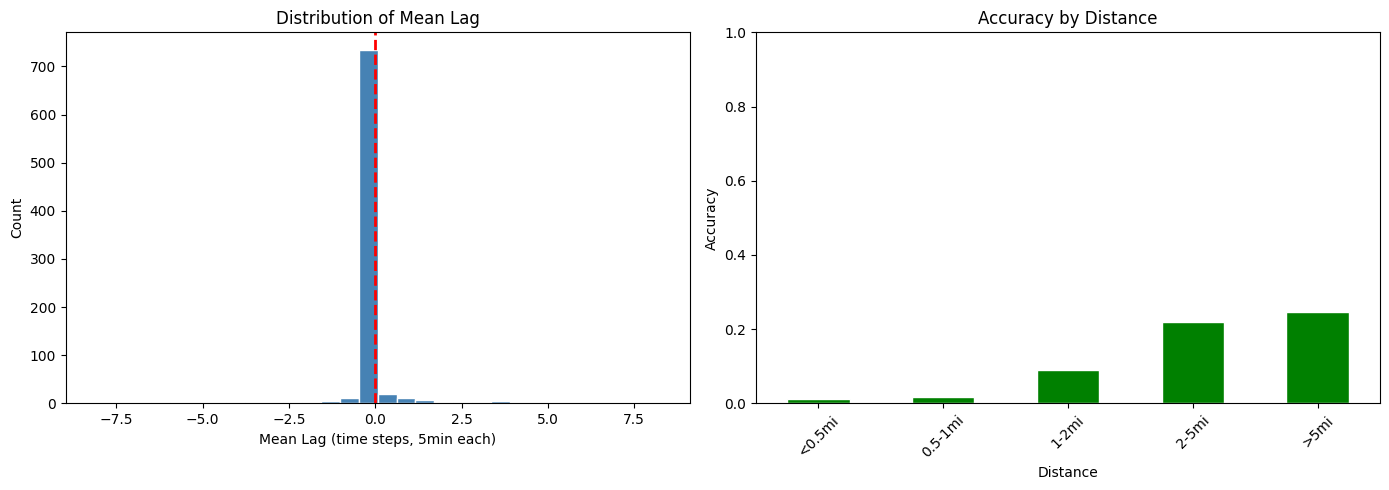

In [31]:
# 滞后分布
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 平均滞后分布
valid_lags = results_df['Mean_Lag'].dropna()
axes[0].hist(valid_lags, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_xlabel('Mean Lag (time steps, 5min each)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Mean Lag')

# 精度 vs 距离
dist_acc = results_df.groupby('Dist_Bin')['Correct'].mean()
dist_acc.plot(kind='bar', ax=axes[1], color='green', edgecolor='white')
axes[1].set_xlabel('Distance')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy by Distance')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45)
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'direction_inference_stats.png'), dpi=150)
plt.show()

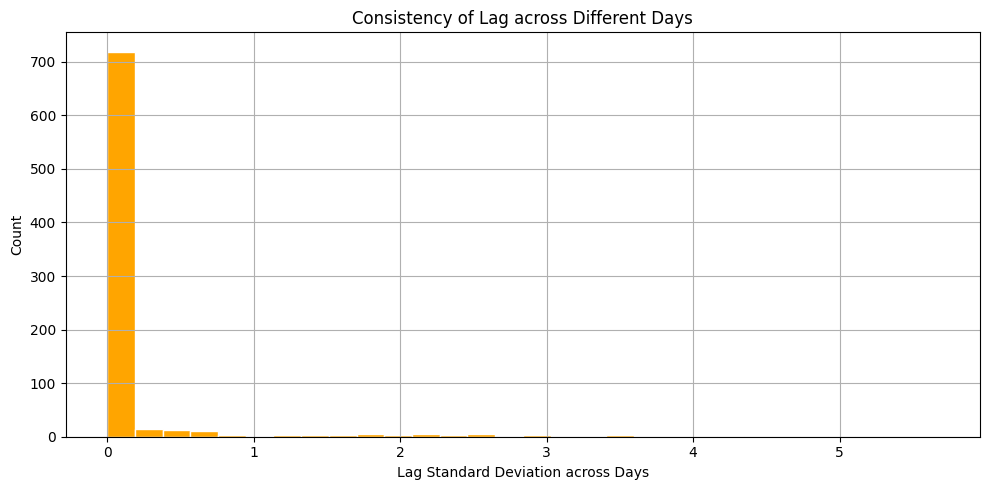

滞后标准差统计:
count    814.00
mean       0.19
std        0.68
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        5.67
Name: Lag_Std, dtype: float64


In [32]:
# 每天滞后的一致性
lag_cols = [f'Lag_{d}' for d in day_names]
lag_matrix = results_df[lag_cols].values

# 计算每对的滞后标准差（一致性指标）
results_df['Lag_Std'] = np.nanstd(lag_matrix, axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
results_df['Lag_Std'].dropna().hist(bins=30, ax=ax, color='orange', edgecolor='white')
ax.set_xlabel('Lag Standard Deviation across Days')
ax.set_ylabel('Count')
ax.set_title('Consistency of Lag across Different Days')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lag_consistency.png'), dpi=150)
plt.show()

print(f"滞后标准差统计:")
print(results_df['Lag_Std'].describe().round(2))

In [33]:
# 查看预测错误的案例
print("预测错误的案例（前20个）:")
wrong = results_df[~results_df['Correct'] & (results_df['Pred_Source'] != 'uncertain')]
display(wrong[['Node1', 'Node2', 'Fwy', 'Dir', 'Distance', 'Mean_Lag', 
               'True_Source', 'Pred_Source']].head(20))

预测错误的案例（前20个）:


,Node1,Node2,Fwy,Dir,Distance,Mean_Lag,True_Source,Pred_Source
10,3102013,3102014,12,E,0.047,-3.285714,3102013,3102014
14,3010012,3413054,12,W,0.358,3.857143,3413054,3010012
33,3022011,3085064,20,W,19.404,3.285714,3085064,3022011
34,3085064,3423017,20,W,26.307,1.714286,3423017,3085064
49,318603,3411041,28,W,7.698,1.000000,3411041,318603
54,3411011,3423021,49,N,9.208,-0.571429,3411011,3423021
56,3411014,3423024,49,S,9.208,1.714286,3423024,3411014
76,316074,316073,5,N,0.004,-0.142857,316074,316073
104,3420042,3420051,5,N,4.466,-0.142857,3420042,3420051
234,3089061,3089022,50,E,0.167,-0.714286,3089061,3089022


## 9. 保存结果

In [34]:
# 保存完整结果
output_path = os.path.join(OUTPUT_DIR, 'direction_inference_results.csv')
results_df.to_csv(output_path, index=False)
print(f"结果已保存: {output_path}")

# 保存摘要
summary = f"""
边方向推断结果摘要
==================

数据: pems_5min_merged.csv (2025年)
方法: 互相关分析 + 按星期聚合

总传感器对数: {total}
有效预测数: {len(valid)} ({len(valid)/total*100:.1f}%)
不确定数: {uncertain} ({uncertain/total*100:.1f}%)

整体精度: {correct/total*100:.1f}%
有效预测精度: {valid['Correct'].sum()/len(valid)*100:.1f}%

按方向:
{dir_stats.to_string()}

按距离:
{dist_stats.to_string()}
"""

with open(os.path.join(OUTPUT_DIR, 'direction_inference_summary.txt'), 'w') as f:
    f.write(summary)
print(f"摘要已保存: direction_inference_summary.txt")

结果已保存: ../output/edge_inference/direction_inference_results.csv
摘要已保存: direction_inference_summary.txt


---
## 输出文件

| 文件 | 说明 |
|------|------|
| `direction_inference_results.csv` | 完整推断结果 |
| `direction_inference_summary.txt` | 精度摘要 |
| `direction_inference_stats.png` | 滞后分布和精度图 |
| `lag_consistency.png` | 滞后一致性图 |

### 结果字段说明

| 字段 | 说明 |
|------|------|
| Node1, Node2 | 传感器对 |
| True_Source | 理论上游节点（基于 Abs_PM） |
| Pred_Source | 预测上游节点（基于互相关） |
| Mean_Lag | 平均滞后（正=Node1领先） |
| Lag_Mon~Sun | 各天的滞后 |
| Correct | 预测是否正确 |